Detected 4 plastic items in 0.01 seconds


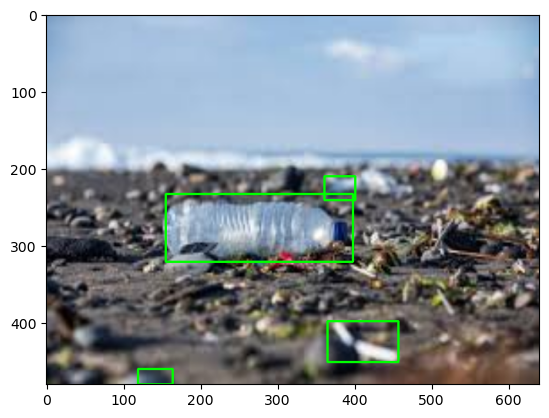

In [11]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

def detect_plastic(image_path):
    # Step 3.1: Load image
    img = cv2.imread(image_path)
    if img is None:
        print("Error loading image")
        return None
    
    # Resize for faster processing (optional, simulate low-res camera)
    img = cv2.resize(img, (640, 480))
    
    # Step 3.2: Convert to HSV for color thresholding
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Define color ranges for common plastics (adjust based on your targets):
    # - Blue bottles: Hue 100-130
    # - White/transparent bags: Low saturation, high value
    # - General plastics: Combine multiple masks
    lower_blue = np.array([100, 50, 50])  # Example for blue plastics
    upper_blue = np.array([130, 255, 255])
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
    
    lower_white = np.array([0, 0, 200])   # Example for white/transparent
    upper_white = np.array([180, 30, 255])
    mask_white = cv2.inRange(hsv, lower_white, upper_white)
    
    
    # Combine masks (for multi-color plastics)
    mask = cv2.bitwise_or(mask_blue, mask_white)
    
    # Step 3.3: Apply morphological operations to clean noise
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.erode(mask, kernel, iterations=1)
    mask = cv2.dilate(mask, kernel, iterations=2)
    
    # Step 3.4: Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Step 3.5: Filter contours by shape and size
    detected = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 500:  # Ignore small noise (adjust based on image size)
            continue
        
        # Approximate shape
        approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), closed=True)
        
        # Filter by shape (e.g., bottles ~ circular/elliptical, wrappers ~ irregular)
        # Circularity: 4*pi*area / perimeter^2 (close to 1 for circles)
        perimeter = cv2.arcLength(cnt, True)
        circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0
        
        # Example filters:
        # - Bottles: High circularity (>0.5)
        # - Bags/wrappers: Low circularity (<0.5), larger area
        if 0.3 < circularity < 0.8 or len(approx) > 10:  # Adjust for your needs
            x, y, w, h = cv2.boundingRect(cnt)
            detected.append((x, y, w, h))
            cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw box
    
    # Step 3.6: Output results
    return img, len(detected)

# Example usage
if __name__ == "__main__":
    start_time = time.time()
    output_img, num_detected = detect_plastic(r"C:\Users\User\OneDrive\Documents\Capstone\Input_image\bottle_image.jpg")  # Replace with your image path
    if output_img is not None:
        print(f"Detected {num_detected} plastic items in {time.time() - start_time:.2f} seconds")
        plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
        plt.show()
        cv2.imwrite("output_detected.jpg", output_img)  # Save for report

Detected 12 plastic items in 0.18 seconds


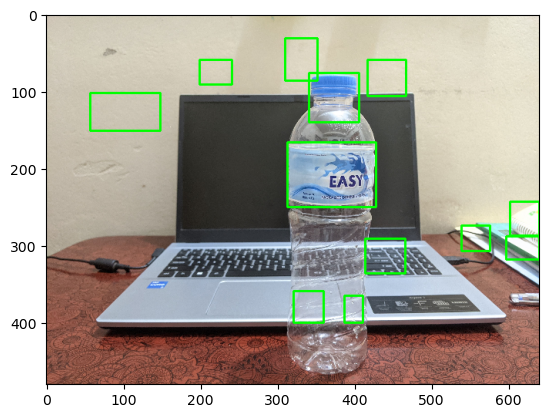

In [12]:
# Example usage
if __name__ == "__main__":
    start_time = time.time()
    output_img, num_detected = detect_plastic(r"C:\Users\User\Downloads\PXL_20260222_104259300.jpg")  # Replace with your image path
    if output_img is not None:
        print(f"Detected {num_detected} plastic items in {time.time() - start_time:.2f} seconds")
        plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
        plt.show()
        cv2.imwrite("output_detected.jpg", output_img)  # Save for report

Detected 3 plastic items in 0.17 seconds


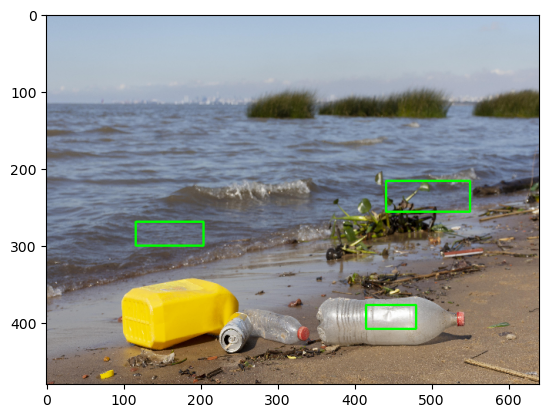

In [7]:
# Example usage
if __name__ == "__main__":
    start_time = time.time()
    output_img, num_detected = detect_plastic(r"C:\Users\User\Downloads\pollution-concept-with-plastic-waste.jpg")  # Replace with your image path
    if output_img is not None:
        print(f"Detected {num_detected} plastic items in {time.time() - start_time:.2f} seconds")
        plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
        plt.show()
        cv2.imwrite("output_detected.jpg", output_img)  # Save for report

Detected 5 plastic items in 0.08 seconds


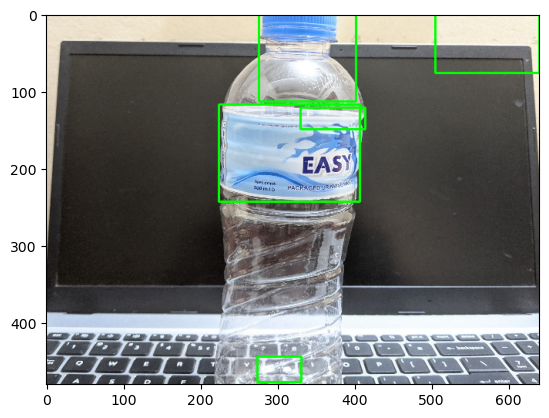

In [13]:
# Example usage
if __name__ == "__main__":
    start_time = time.time()
    output_img, num_detected = detect_plastic(r"C:\Users\User\Downloads\PXL_20260222_1043242441.jpg")  # Replace with your image path
    if output_img is not None:
        print(f"Detected {num_detected} plastic items in {time.time() - start_time:.2f} seconds")
        plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
        plt.show()
        cv2.imwrite("output_detected.jpg", output_img)  # Save for report